# Fixed point optimization of a cubic function

In this lab, we implement a fixed-point version of a monic cubic function:

```python
   y = x**3 + a[2]*x**2 + a[1]*x + a[0]
```

We will follow the similar sequence of steps as the [fixed point demo](https://sdrangan.github.io/hwdesign/docs/demos/fixp/).

## Floating Point Version

We begin by writing a floating point version of the function.

In [2]:
import numpy as np
from numpy.typing import NDArray

def cubic_float(
    x: NDArray[np.float64],  # shape (n,)
    a: NDArray[np.float64],  # shape (n, 3)
) -> NDArray[np.float64]:
    """
    Evaluate a monic cubic polynomial at points x:

        y = a[:,0] + a[:,1] * x + a[:,2] * x**2 +  x**3
    """
    y = a[:,0] + a[:,1] * x + a[:,2] * x**2 + x**3
    return y

To illustrate, we plot the function for some values:


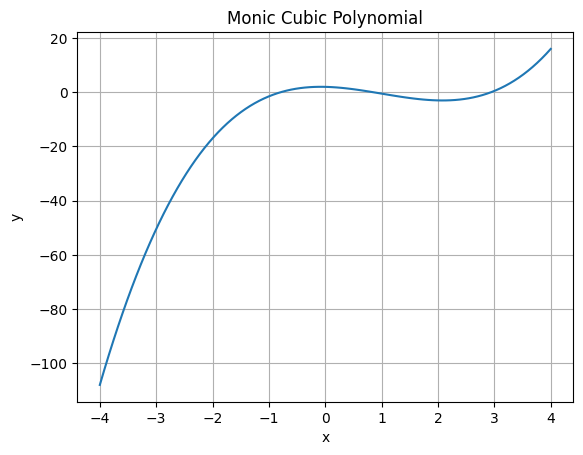

In [3]:
nplot = 100
xplot = np.linspace(-4.0, 4.0, nplot)
aplot = np.array([2.0, -0.5, -3.0])
aplot = aplot[None,:].repeat(nplot, axis=0)

yplot = cubic_float(xplot, aplot)
import matplotlib.pyplot as plt
plt.plot(xplot, yplot)
plt.title("Monic Cubic Polynomial")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

## Create a Fixed Point Version

We now create a fixed point version. THere are several ways to handle overflow.
One way is to saturate after each product.  For example, suppose that `xint`
is the integer representation of `x` in `Q(wid,fbits)`.  We can implement the 
product such as `xint*xint`, as follows:

```python
x2int = saturate((xint * xint) >> fbits, wid)
```

This product `(xint * xint) >> fbits` will be in `Q(wid2, fbits)` where 
`wid2= 2*wid-fbits`.   We then saturate each product back to `wid` bits.

Similarly, we can use:

```python
x3int = saturate((xint * x2int) >> fbits, wid_acc)
```

to get the cubic term.  Use this pattern to complete the following code.

In [5]:
#import sys
#if "google.colab" in sys.modules:
#    !pip install git+https://github.com/sdrangan/hwdesign.git

from xilinxutils.fixputils import truncate, saturate

In [ ]:
!uv pip install git+https://github.com/sdrangan/hwdesign.git

In [10]:
def cubic_fixed(
        xint : NDArray[np.int64],  # shape (n,)
        aint : NDArray[np.int64],  # shape (n, 4)
        wid : int = 16,   # total bit width
        fbits : int = 8
    ) -> NDArray[np.int64]:
    """
    Evaluate a monic cubic polynomial in fixed point:
        y = a[:,0] + a[:,1] * x + a[:,2] * x**2 + x**3


    Parameters
    ----------
    xint : NDArray[np.int64]
        Input values in Q(wid, fbits), shape (n,)
    aint : NDArray[np.int64]
        Coefficients in Q(wid, fbits), shape (n, deg+1) where deg=3
    wid : int
        Total bit width of inputs and outputs
    fbits : int
        Number of fractional bits in inputs and outputs
    
        
    Returns
    -------
    yint : NDArray[np.int64]
        Output values in Q(wid, fbits), shape (n,)
    """

    x2int = saturate((xint * xint) >> fbits, wid)
    
    x3int = saturate((x2int * xint) >> fbits, wid)

    term0 = aint[:, 0]
    term1 = saturate((aint[:, 1] * xint) >> fbits, wid)
    term2 = saturate((aint[:, 2] * x2int) >> fbits, wid)
    
    yint = saturate(term0 + term1 + term2 + x3int, wid)
    
    return yint

Now plot a comparison of the the floating and fixed point function over the set of values xplot.
This part will not be submitted, but it will help you make sure that your algorithm is working correctly.
You should see:

- For `wid=16`, `fbits=8`, the floating and fixed point versions match well over this range of inputs
- For `wid=16`, `fbits=12`, the fixed point version clearly saturates


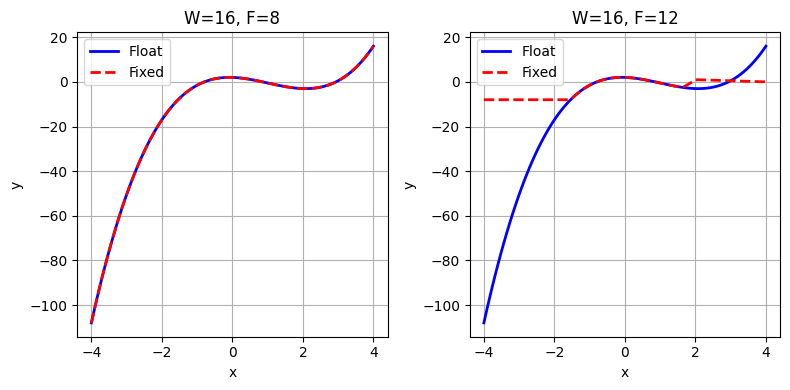

In [12]:
# Bit widths to test
wid_plot = [16, 16]
fbits_plot = [8, 12]
nwid = len(wid_plot)


plt.subplots(1, nwid,figsize=(4*nwid, 4))

for i in range(nwid):
    wid = wid_plot[i]
    fbits = fbits_plot[i]
    
    # Compute fixed-point outputs for this bit width
    xplot_int = np.round(xplot * (2**fbits)).astype(np.int64)
    aplot_int = np.round(aplot * (2**fbits)).astype(np.int64)
    yplot_int = cubic_fixed(xplot_int, aplot_int, wid=wid, fbits=fbits)
    yplot_fix = yplot_int.astype(np.float64) / (2**fbits)
    
    # Plot the fixed and floating point results in a subplot
    plt.subplot(1, nwid, i+1)
    plt.plot(xplot, yplot, 'b-', label='Float', linewidth=2)
    plt.plot(xplot, yplot_fix, 'r--', label='Fixed', linewidth=2)
    plt.title(f'W={wid}, F={fbits}')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.legend()
    plt.grid(True)

plt.tight_layout()
plt.show()

## Generate Test Vectors

As in the demo, you could optimize the bit widths.  But, we skip this step.  Here we just generate test vectors.  We will generate two test vectors:

- `test_vectors/tv_w16_f8.csv` for `wid=16` and `fbits=8`.  In this test case, there are no overflows.
This test case will ensure that the regular logic in the SV implmentation matches the python implementation.
- `test_vectors/tv_w16_f12.csv` for `wid=16` and `fbits=12`.  In this test case, there is significant overflow.  
The test case will good to test the SV implementation performs overflow exactly in a manner that the python implementation does.

The test also measures the MSE:  You should see approximately the following values.
Specifically, with `fbits=8`, you get a very good approximation, but with `fbits=12`,
the logic begins to saturate.

| W (Total Bits) | F (Fraction Bits) | Expected MSE      |
|----------------|-------------------|-------------------|
| 16             | 8                 | ~1e-5       |
| 16             | 12                | ~0.2              |



In [ ]:
import os
import pandas as pd

# Create test_vectors directory if it doesn't exist
os.makedirs('test_outputs', exist_ok=True)

# Generate random samples
nsamp = 100
deg = 3
a = np.random.uniform(-4.0, 4.0, (nsamp, deg))
x = np.random.uniform(-2.0, 2.0, nsamp)

# Fix parameters for test vector generation
wid_acc = 32 
wid = 16
fbits_test = [8, 12]

for fbits in fbits_test:
    print(f'\nGenerating test vectors for W={wid}, F={fbits}')

    # Compute floating point output
    y = cubic_float(x, a)

    # Convert to fixed point representation of inputs
    xint = np.round(x * (2**fbits)).astype(np.int64)
    aint = np.round(a * (2**fbits)).astype(np.int64)

    # Compute fixed point outputs
    yint = cubic_fixed(
        xint=xint, 
        aint=aint, 
        wid=wid, 
        fbits=fbits)
    yfix = yint.astype(np.float64) / (2**fbits)

    mse = np.mean((y - yfix)**2)/ np.mean(y**2)
    print("Mean squared error: %12.4e" % mse)

    # Create DataFrame with all values
    df = pd.DataFrame({
        'xint': xint,
        'aint0': aint[:, 0],
        'aint1': aint[:, 1],
        'aint2': aint[:, 2],
        'y': y,
        'yint': yint,
        'yfix': yfix
    })

    # Save to CSV file
    csv_filename = f'test_outputs/tv_w{wid}_f{fbits}.csv'
    df.to_csv(csv_filename, index=False)
    print(f"Test vectors saved to {csv_filename}")
    print(f"Number of test vectors: {len(df)}")
    print(f"\nFirst 5 rows:")
    print(df.head())


Generating test vectors for W=16, F=8
Mean squared error:   4.4722e-06
Test vectors saved to test_outputs/tv_w16_f8.csv
Number of test vectors: 100

First 5 rows:
   xint  aint0  aint1  aint2         y  yint      yfix
0   399   -462    -15   -192  0.072937    15  0.058594
1   415    269    489   -840 -0.215472   -55 -0.214844
2  -233    502    203    204  1.145332   292  1.140625
3   151   -742    722   -899 -2.251553  -578 -2.257812
4    76   -186    644    -43  0.034980     7  0.027344

Generating test vectors for W=16, F=12
Mean squared error:   1.6541e-01
Test vectors saved to test_outputs/tv_w16_f12.csv
Number of test vectors: 100

First 5 rows:
   xint  aint0  aint1  aint2         y  yint      yfix
0  6388  -7391   -247  -3067  0.072937   299  0.072998
1  6646   4309   7828 -13442 -0.215472  1738  0.424316
2 -3725   8034   3255   3262  1.145332  4689  1.144775
3  2410 -11871  11549 -14388 -2.251553 -9221 -2.251221
4  1219  -2972  10307   -682  0.034980   141  0.034424
